# Análisis de estabilidad temporal por trimestre

En sistemas de farmacovigilancia basados en reportes espontáneos como **FAERS**, la detección de señales mediante métricas de desproporcionalidad (p. ej., **ROR/PRR**) puede verse afectada por variaciones naturales en el flujo de reportes: cambios en el volumen trimestral, modificaciones en prácticas de prescripción, eventos mediáticos, campañas regulatorias, o diferencias de captura/curación de datos. Por ello, además de identificar señales en un corte agregado, es fundamental evaluar su **estabilidad temporal**: es decir, determinar si las señales detectadas son **persistentes** (aparecen de forma consistente en múltiples trimestres) o **transitorias** (aparecen en un único periodo y podrían ser producto de ruido, rareza o cambios temporales en el reporte).

En esta parte del trabajo nos centraremos en cuantificar la **robustez y reproducibilidad temporal** de las señales identificadas, utilizando datos trimestrales de 2025. La estabilidad temporal aporta evidencia adicional para priorizar señales: en general, una señal que se mantiene en varios trimestres y conserva su posición relativa en los rankings es más plausible como candidata para revisión clínica posterior que una señal que surge solo en un trimestre con bajo soporte.

### Alcance metodológico
El análisis se realiza sobre el esquema **PS (Primary Suspect)** como configuración principal, ya que suele ofrecer mayor interpretabilidad clínica al restringir a medicamentos señalados como sospechosos principales. Además, se utiliza una vista **clinical-only** que excluye un conjunto de términos MedDRA PT administrativos/operacionales (`admin-like`) para evitar que fenómenos de uso del producto, calidad o errores de medicación dominen los rankings clínicos. (Estos PTs no se eliminan, sino que se separan para análisis complementario.)



## Pasos del análisis que realizaremos

1. **Carga e integración trimestral**
   - Cargar, por trimestre, las tablas `drugs`, `reactions` y `reports`.
   - Construir los pares **(fármaco, reacción)** por `safetyreportid`.
   - Normalizar llaves (`drug_key`, `reaction_pt`) y conservar metadatos (`quarter`, `occurcountry`, `receiptdate`).

2. **Definición del esquema principal por rol del fármaco**
   - Mapear `drugcharacterization` → `role_cod` (PS/SS/C/I).
   - Construir tres esquemas:
     - **PS** (principal),
     - **PS+SS** (sensibilidad),
     - **ALL** (sensibilidad amplia).
   - Seleccionar **PS** como conjunto base para el análisis temporal.

3. **Separación de PTs administrativos/operacionales (clinical-only)**
   - Definir un conjunto `admin-like` (p. ej., `OFF LABEL USE`, `DRUG INEFFECTIVE`, `MEDICATION ERROR`, `DEVICE ISSUE`, etc.).
   - Crear dos vistas:
     - **ALL-PTs** (sin filtrar),
     - **clinical-only** (excluye admin-like).
   - Usar **PS + clinical-only** como configuración principal para las métricas de estabilidad.

4. **Cálculo de señales por trimestre**
   - Para cada trimestre (Q1–Q4), calcular:
     - conteos 2×2 (`n11, n10, n01, n00`),
     - **ROR** con IC95% (usando `ROR_L95` como criterio conservador),
     - **PRR**,
     - criterios de señal (por ejemplo, `n11 ≥ MIN_N11` y `ROR_L95 > 1`).
   - Generar un **resumen por trimestre** con:
     - número de reportes,
     - número de pares evaluados,
     - número de señales positivas (ROR/PRR/ambos).

5. **Persistencia temporal (señales repetidas en múltiples trimestres)**
   - Construir una matriz de presencia 0/1 por par fármaco–reacción y trimestre.
   - Calcular la **distribución de persistencia**:
     - señales que aparecen en 1, 2, 3 o 4 trimestres.
   - Identificar el subconjunto de señales **persistentes 4/4** (máxima estabilidad).

6. **Estabilidad entre trimestres (consistencia del conjunto de señales)**
   - Medir similitud entre conjuntos de señales de distintos trimestres mediante **Jaccard**:
     - Jaccard global sobre todas las señales positivas,
     - Jaccard en el **Top-k** (p. ej., Top-100) por `priority_score` para evaluar estabilidad del ranking de priorización.

7. **Estabilidad del orden de priorización (ranking)**
   - Para los pares comunes del Top-k entre dos trimestres:
     - medir correlación **Spearman** de los ranks (consistencia del orden relativo).
   - Reportar también el tamaño de la intersección Top-k (número de pares comunes).

8. **Visualización y exportables para artículo**
   - Generar figuras:
     - barras de persistencia (1–4 trimestres),
     - heatmaps de Jaccard global,
     - heatmaps de Jaccard Top-k,
     - heatmaps de Spearman (Top-k),
     - heatmaps de número de pares comunes (Top-k).
   - Exportar tablas:
     - `summary_quarters`,
     - `persist_dist`,
     - lista de señales persistentes 4/4 con agregados (soporte e intensidad),
     - matrices de estabilidad (Jaccard/Spearman/intersección).


### Resultado esperado
Al finalizar, obtendremos una caracterización cuantitativa de la estabilidad temporal de las señales, permitiendo distinguir:
- **señales persistentes** (robustas y prioritarias),
- **señales transitorias** (candidatas a revisión adicional o sensibilidad a umbrales),
y cuantificar tanto la estabilidad del **conjunto de señales** como la estabilidad del **ranking** en el tiempo.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import seaborn as sns

### Carga e integración trimestral de FAERS (drugs + reactions + reports)

En esta celda construiremos la base de trabajo **a nivel de reporte (`safetyreportid`)** integrando, para cada trimestre, las tres tablas disponibles: **`drugs`**, **`reactions`** y **`reports`**. Primero definimos la ruta base y la lista de carpetas trimestrales, junto con funciones auxiliares para (i) localizar los CSV por patrón de nombre, (ii) leerlos de forma robusta (corrigiendo posibles BOM con `utf-8-sig`), (iii) normalizar nombres de columnas, y (iv) estandarizar llaves de texto.

Después, para cada trimestre:
- cargamos los tres archivos,
- verificamos que existan las columnas mínimas requeridas,
- construimos `drug_key` si no viene en el archivo (usando `activesubstancename` como fuente preferida),
- limpiamos `reaction_pt`,
- reducimos a columnas útiles y tipificamos `safetyreportid`,
- deduplicamos filas para evitar explosiones artificiales en el `merge`,
- generamos los pares **(fármaco, reacción)** mediante `drugs × reactions` por `safetyreportid`,
- enriquecemos con metadatos de `reports` (p. ej., `occurcountry`, `receiptdate`),
- y acumulamos los resultados en listas.

Finalmente, concatenamos los cuatro trimestres en un solo `DataFrame` (`pairs`) y aseguramos que `quarter` sea una variable categórica ordenada (Q1→Q4) para facilitar los análisis y visualizaciones posteriores.

In [14]:
BASE_ROOT = Path("data_processed")
quarters = ["q1_2025_sample100k", "q2_2025_sample100k", "q3_2025_sample100k", "q4_2025_sample100k"]
DEBUG = False  

def find_one_csv(qdir: Path, pattern_list):
    for pat in pattern_list:
        hits = list(qdir.glob(pat))
        if hits:
            return hits[0]
    return None

def read_csv_robust(fp: Path):
    # utf-8-sig elimina BOM si existe
    return pd.read_csv(fp, low_memory=False, encoding="utf-8-sig")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .map(lambda c: str(c).replace("\ufeff", "").strip().lower())
    )
    return df

def clean_text_key(s: pd.Series) -> pd.Series:
    # normalización ligera para llaves de texto
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.str.replace(r"[^A-Z0-9 /+\-().,]", "", regex=True)
    s = s.replace({"NAN": np.nan, "NONE": np.nan, "": np.nan})
    return s


all_pairs = []
all_reports = []

for q in quarters:
    qdir = BASE_ROOT / q

    fp_drugs = find_one_csv(qdir, ["*drugs*.csv"])
    fp_reac  = find_one_csv(qdir, ["*reactions*.csv"])
    fp_rep   = find_one_csv(qdir, ["*reports*.csv"])

    if not (fp_drugs and fp_reac and fp_rep):
        print(f"[WARN] Faltan archivos en {qdir}")
        print("drugs:", fp_drugs)
        print("reactions:", fp_reac)
        print("reports:", fp_rep)
        continue

    print(f"\n=== {q} ===")
    print("drugs     :", fp_drugs.name)
    print("reactions :", fp_reac.name)
    print("reports   :", fp_rep.name)

    # CSV
    d = read_csv_robust(fp_drugs)
    r = read_csv_robust(fp_reac)
    rep = read_csv_robust(fp_rep)

    # Normalizar nombres de columnas
    d = normalize_columns(d)
    r = normalize_columns(r)
    rep = normalize_columns(rep)

    if DEBUG:
        print("drugs cols:", list(d.columns))
        print("reac  cols:", list(r.columns))
        print("rep   cols:", list(rep.columns))

    # Validar columnas mínimas
    if "safetyreportid" not in d.columns:
        raise ValueError(f"{q}: drugs no tiene 'safetyreportid'")
    if "safetyreportid" not in r.columns:
        raise ValueError(f"{q}: reactions no tiene 'safetyreportid'")
    if "reaction_pt" not in r.columns:
        raise ValueError(f"{q}: reactions no tiene 'reaction_pt'")
    if "safetyreportid" not in rep.columns:
        raise ValueError(f"{q}: reports no tiene 'safetyreportid'")

    # Crear drug_key si no existe
    if "drug_key" not in d.columns:
        if "activesubstancename" in d.columns:
            d["drug_key"] = clean_text_key(d["activesubstancename"])
            source_used = "activesubstancename"
        elif "medicinalproduct" in d.columns:
            d["drug_key"] = clean_text_key(d["medicinalproduct"])
            source_used = "medicinalproduct"
        else:
            raise ValueError(
                f"{q}: drugs no tiene 'drug_key' ni columnas para construirlo "
                f"(activesubstancename/medicinalproduct)."
            )
        print(f"[INFO] {q}: drug_key construido desde '{source_used}'")
    else:
        d["drug_key"] = clean_text_key(d["drug_key"])

    # Limpieza reaction_pt
    r["reaction_pt"] = clean_text_key(r["reaction_pt"])

    # Mantener columnas útiles
    keep_d = ["safetyreportid", "drug_key"]
    for c in ["drugcharacterization", "medicinalproduct", "activesubstancename"]:
        if c in d.columns:
            keep_d.append(c)
    d = d[keep_d].copy()

    keep_r = ["safetyreportid", "reaction_pt"]
    if "reaction_meddra_version_pt" in r.columns:
        keep_r.append("reaction_meddra_version_pt")
    r = r[keep_r].copy()

    keep_rep = ["safetyreportid"]
    for c in ["occurcountry", "receiptdate"]:
        if c in rep.columns:
            keep_rep.append(c)
    rep = rep[keep_rep].copy()

    # Tipos
    for x in [d, r, rep]:
        x["safetyreportid"] = pd.to_numeric(x["safetyreportid"], errors="coerce")
        x.dropna(subset=["safetyreportid"], inplace=True)

    if "drugcharacterization" in d.columns:
        d["drugcharacterization"] = pd.to_numeric(d["drugcharacterization"], errors="coerce")

    # Quitar vacíos en llaves
    d = d.dropna(subset=["drug_key"])
    r = r.dropna(subset=["reaction_pt"])

    # Deduplicar bases antes del merge
    d = d.drop_duplicates()
    r = r.drop_duplicates()
    rep = rep.drop_duplicates(subset=["safetyreportid"])

    # Merge drugs x reactions por safetyreportid (genera pares)
    pairs_q = d.merge(r, on="safetyreportid", how="inner", validate="m:m")
    pairs_q["quarter"] = q

    # Enriquecer con reports 
    pairs_q = pairs_q.merge(rep, on="safetyreportid", how="left", validate="m:1")

    all_pairs.append(pairs_q)
    all_reports.append(rep.assign(quarter=q))

    print("pairs_q shape:", pairs_q.shape)
    print("reports_q shape:", rep.shape)
    print("drug_key nulos:", pairs_q["drug_key"].isna().sum(), "| reaction_pt nulos:", pairs_q["reaction_pt"].isna().sum())

if not all_pairs:
    raise ValueError("No se pudo construir ningún trimestre.")

pairs = pd.concat(all_pairs, ignore_index=True)
reports_all = pd.concat(all_reports, ignore_index=True)

# Orden de trimestre garantizado
pairs["quarter"] = pd.Categorical(pairs["quarter"], categories=quarters, ordered=True)
reports_all["quarter"] = pd.Categorical(reports_all["quarter"], categories=quarters, ordered=True)

print("\n=== TOTAL ===")
print("pairs shape:", pairs.shape)
print("columns:", list(pairs.columns))
print("quarters:\n", pairs["quarter"].value_counts(dropna=False))


=== q1_2025_sample100k ===
drugs     : q1_drugs_100k.csv
reactions : q1_reactions_100k.csv
reports   : q1_reports_100k.csv
[INFO] q1_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (2994020, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 0

=== q2_2025_sample100k ===
drugs     : q2_drugs_100k.csv
reactions : q2_reactions_100k.csv
reports   : q2_reports_100k.csv
[INFO] q2_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (2469562, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 0

=== q3_2025_sample100k ===
drugs     : q3_drugs_100k.csv
reactions : q3_reactions_100k.csv
reports   : q3_reports_100k.csv
[INFO] q3_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (3051509, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 0

=== q4_2025_sample100k ===
drugs     : q4_drugs_100k.csv
reactions : q4_reactions_100k.csv
reports   : q4

La salida confirma que, para cada trimestre (Q1–Q4 2025), se localizaron y cargaron correctamente los archivos `drugs`, `reactions` y `reports`. Como `drug_key` no venía en los archivos de `drugs`, se construyó automáticamente a partir de `activesubstancename` en los cuatro trimestres, sin generar valores faltantes. Tras unir `drugs × reactions` por `safetyreportid` (y enriquecer con metadatos de `reports`), se obtuvieron bases trimestrales `pairs_q` de tamaño aproximado **2.47M–3.06M** filas (cada una con **10** columnas), mientras que `reports_q` conserva **100,000** reportes por trimestre. El control de calidad indica **0 nulos** en `drug_key` y `reaction_pt` en todos los casos. Finalmente, al concatenar los cuatro trimestres se construyó `pairs` con **11,570,960** filas y **10** columnas, con una distribución por trimestre consistente (Q4≈3.06M, Q3≈3.05M, Q1≈2.99M, Q2≈2.47M), dejando la base lista para los cálculos de señales y el análisis de estabilidad temporal.

### Mapeo del rol del fármaco y definición de esquemas de análisis (PS, PS+SS, ALL)

A continuación transformaremos la variable `drugcharacterization` (codificada numéricamente en FAERS) en una etiqueta interpretable `role_cod` que indica el **rol del fármaco dentro del reporte**: **PS** (*Primary Suspect*), **SS** (*Secondary Suspect*), **C** (*Concomitant*), **I** (*Interacting*), y, en algunos casos, **O**. Con este mapeo podremos construir tres subconjuntos de datos para comparar resultados: **PS** (solo sospechoso principal), **PS+SS** (sospechoso principal y secundario) y **ALL** (todos los roles). Además de reportar la distribución de roles en número de filas y en reportes únicos (`safetyreportid`), definiremos **PS como el esquema principal** para el análisis de estabilidad temporal, dejando PS+SS y ALL como alternativas de sensibilidad.

In [15]:
# mapear roles (PS/SS/C/I) y crear esquemas PS, PS+SS, ALL

# Mapeo típico FAERS para drugcharacterization
# 1=PS, 2=SS, 3=C, 4=I, 5=O
role_map = {1: "PS", 2: "SS", 3: "C", 4: "I", 5: "O"}

pairs["drugcharacterization"] = pd.to_numeric(pairs["drugcharacterization"], errors="coerce")
pairs["role_cod"] = pairs["drugcharacterization"].map(role_map).fillna("UNK")

print("Distribución de roles (filas):")
print(pairs["role_cod"].value_counts(dropna=False).rename_axis("role_cod").reset_index(name="n"))

print("\nReportes únicos por rol (safetyreportid):")
print(pairs.groupby("role_cod")["safetyreportid"].nunique().sort_values(ascending=False)
        .rename("n_reports").reset_index())

# Esquemas
pairs_ps = pairs.loc[pairs["role_cod"].eq("PS")].copy()
pairs_ps_ss = pairs.loc[pairs["role_cod"].isin(["PS", "SS"])].copy()
pairs_all = pairs.copy()

print("\n=== Tamaños por esquema (filas) ===")
print("PS    :", len(pairs_ps))
print("PS+SS :", len(pairs_ps_ss))
print("ALL   :", len(pairs_all))

print("\n=== Reportes únicos por esquema ===")
print("PS    :", pairs_ps["safetyreportid"].nunique())
print("PS+SS :", pairs_ps_ss["safetyreportid"].nunique())
print("ALL   :", pairs_all["safetyreportid"].nunique())

# Definir esquema principal para estabilidad temporal 
pairs_main = pairs_ps
MAIN_SCHEME = "PS"
print("\nEsquema principal para estabilidad temporal:", MAIN_SCHEME)

Distribución de roles (filas):
  role_cod        n
0       PS  6388933
1       SS  5128646
2        C    53255
3        I      121
4      UNK        5

Reportes únicos por rol (safetyreportid):
  role_cod  n_reports
0       PS     388573
1       SS     104362
2        C       2295
3        I         33
4      UNK          1

=== Tamaños por esquema (filas) ===
PS    : 6388933
PS+SS : 11517579
ALL   : 11570960

=== Reportes únicos por esquema ===
PS    : 388573
PS+SS : 389231
ALL   : 390140

Esquema principal para estabilidad temporal: PS


Esto muestra que la mayoría de los registros corresponden a fármacos etiquetados como **sospechosos**: **PS** concentra **6,388,933 filas** y **SS** **5,128,646**, mientras que los roles **concomitante (C)** y **interactuante (I)** son marginales (**53,255** y **121** filas, respectivamente), con solo **5** filas sin mapeo (`UNK`). Al contar reportes únicos (`safetyreportid`), **PS** cubre **388,573** reportes, y al agregar **SS** el total sube solo a **389,231**, muy cercano al total **ALL** (**390,140**). Esto indica que el esquema **PS** conserva prácticamente toda la cobertura de reportes, pero restringe los pares a aquellos donde el fármaco fue marcado como sospechoso principal, lo que mejora la interpretabilidad clínica. Por esta razón se define **PS como el esquema principal** para el análisis de estabilidad temporal, dejando **PS+SS** y **ALL** como análisis de sensibilidad.

### Separación de PTs administrativos/operacionales y creación de vistas (clinical-only vs all-PTs)

En esta celda definiremos un conjunto de términos MedDRA PT **administrativos/operacionales** (`admin_patterns`) que suelen reflejar aspectos de uso del producto, fallas terapéuticas, errores de medicación o problemas de calidad/dispositivo (por ejemplo, *OFF LABEL USE*, *DRUG INEFFECTIVE*, *MEDICATION ERROR*, *DEVICE ISSUE*). Con esta lista construiremos `admin_set` y estandarizaremos `reaction_pt` para poder identificar de forma consistente estos PTs en los datos. A partir de ello crearemos dos vistas del esquema principal **PS**: (i) **`pairs_main_allpts`**, que conserva todos los PTs, y (ii) **`pairs_main_clinical`**, que excluye los PTs `admin-like` para enfocarnos en señales más interpretables clínicamente. Finalmente, reportaremos cuántas filas y reportes se clasifican como `admin-like`, verificaremos que la distribución por trimestre se mantenga, y seleccionaremos **PS + clinical-only** como el dataset temporal principal (`pairs_time`) para el análisis de estabilidad.

In [16]:
admin_patterns = [
    "OFF LABEL USE",
    "DRUG INEFFECTIVE",
    "PRODUCT USE IN UNAPPROVED INDICATION",
    "PRODUCT USE ISSUE",
    "INTENTIONAL PRODUCT USE ISSUE",
    "PRODUCT USE COMPLAINT",
    "DRUG INEFFECTIVE FOR UNAPPROVED INDICATION",
    "THERAPEUTIC PRODUCT EFFECT INCOMPLETE",
    "THERAPEUTIC PRODUCT EFFECT DECREASED",
    "THERAPEUTIC RESPONSE DECREASED",
    "THERAPEUTIC RESPONSE SHORTENED",
    "PRODUCT DOSE OMISSION ISSUE",
    "INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION",
    "CONTRAINDICATED PRODUCT ADMINISTERED",
    "INTENTIONAL PRODUCT MISUSE",
    "MEDICATION ERROR",
    "INCORRECT ROUTE OF PRODUCT ADMINISTRATION",
    "INCORRECT PRODUCT ADMINISTRATION DURATION",
    "INTENTIONAL DOSE OMISSION",
    "PRODUCT DOSE OMISSION IN ERROR",
    "WRONG TECHNIQUE IN PRODUCT USAGE PROCESS",
    "PRODUCT ADMINISTRATION INTERRUPTED",
    "PRODUCT QUALITY ISSUE",
    "PRODUCT LABEL CONFUSION",
    "PRODUCT DISTRIBUTION ISSUE",
    "DEVICE ISSUE",
]

admin_set = {x.strip().upper() for x in admin_patterns}

# Normalizar reaction_pt una vez 
pairs_main["reaction_pt"] = pairs_main["reaction_pt"].astype(str).str.strip().str.upper()

# Vistas
pairs_main_allpts = pairs_main.copy()
pairs_main_clinical = pairs_main.loc[~pairs_main["reaction_pt"].isin(admin_set)].copy()

print("=== Vistas para estabilidad temporal (esquema: PS) ===")
print("ALL-PTs    rows:", len(pairs_main_allpts), "| reports:", pairs_main_allpts["safetyreportid"].nunique())
print("Clinical   rows:", len(pairs_main_clinical), "| reports:", pairs_main_clinical["safetyreportid"].nunique())

# Proporción de filas admin-like (en PS)
admin_like_rows = int(pairs_main_allpts["reaction_pt"].isin(admin_set).sum())
print("\nFilas admin-like en PS:", admin_like_rows, f"({admin_like_rows/len(pairs_main_allpts):.3%})")

# Confirmar trimestres
print("\nTrimestres en ALL-PTs:", pairs_main_allpts["quarter"].value_counts().sort_index().to_dict())
print("Trimestres en Clinical:", pairs_main_clinical["quarter"].value_counts().sort_index().to_dict())

# Elegimos por defecto el dataset temporal principal para el paper:
pairs_time = pairs_main_clinical
TIME_LABEL = "PS_clinical"
print("\nDataset temporal seleccionado:", TIME_LABEL)

=== Vistas para estabilidad temporal (esquema: PS) ===
ALL-PTs    rows: 6388933 | reports: 388573
Clinical   rows: 5917248 | reports: 369230

Filas admin-like en PS: 471685 (7.383%)

Trimestres en ALL-PTs: {'q1_2025_sample100k': 1675202, 'q2_2025_sample100k': 1326609, 'q3_2025_sample100k': 1806305, 'q4_2025_sample100k': 1580817}
Trimestres en Clinical: {'q1_2025_sample100k': 1552975, 'q2_2025_sample100k': 1232736, 'q3_2025_sample100k': 1668728, 'q4_2025_sample100k': 1462809}

Dataset temporal seleccionado: PS_clinical


La salida resume el efecto de separar PTs **admin-like** dentro del esquema **PS**. La vista **ALL-PTs** conserva todos los términos y contiene **6,388,933 filas** asociadas a **388,573 reportes**. Al excluir los PTs administrativos/operacionales se obtiene la vista **Clinical**, con **5,917,248 filas** y **369,230 reportes**, lo que muestra que una fracción de reportes contiene al menos un término `admin-like`. En total, se identificaron **471,685 filas admin-like**, equivalentes al **7.383%** de las filas en PS. La distribución por trimestre se mantiene en ambas vistas (con reducciones consistentes en cada periodo), lo que indica que el filtrado no elimina un trimestre de forma desproporcionada. Con base en esto, se selecciona **PS_clinical** como dataset temporal principal (`pairs_time`) para evaluar estabilidad de señales enfocada en términos más interpretables clínicamente.

### Definición de la función de señales (a nivel reporte) y parámetros del análisis

En esta celda fijaremos los parámetros globales del estudio (**`MIN_N11=5`** como umbral mínimo de soporte y **`HALDANE_EPS=0.5`** para la corrección de Haldane–Anscombe) y definiremos una función reutilizable, `build_signal_table_report_level`, para calcular señales de desproporcionalidad **a nivel de reporte (`safetyreportid`)**. La función construye, para cada par fármaco–reacción, los conteos de la tabla 2×2 (`n11, n10, n01, n00`) deduplicando previamente por reporte para evitar sobreconteo, y luego calcula **ROR** con **IC95%** (mediante `ROR_L95` y `ROR_U95`) y **PRR**. Con base en estos resultados, marca señales positivas mediante criterios simples (`n11 ≥ MIN_N11` y `ROR_L95 > 1`, así como `PRR ≥ 2`) y genera un **`priority_score`** que combina fuerza de señal y frecuencia para fines de priorización. Esta función será aplicada de forma idéntica en cada trimestre, garantizando comparabilidad directa en el análisis de estabilidad temporal.

In [17]:
MIN_N11 = 5
HALDANE_EPS = 0.5

def build_signal_table_report_level(df_pairs: pd.DataFrame,
                                    unit_id: str = "safetyreportid",
                                    drug_col: str = "drug_key",
                                    reac_col: str = "reaction_pt",
                                    min_n11: int = 5,
                                    eps: float = 0.5) -> pd.DataFrame:
    """
    Construye tabla de señales (D,A) a nivel reporte (safetyreportid),
    con conteos 2x2, ROR, PRR e IC95%.
    """
    df = df_pairs.copy()
    df = df.dropna(subset=[unit_id, drug_col, reac_col]).copy()

    # Deduplicación por unidad (reporte)
    df4 = df.drop_duplicates([unit_id, drug_col, reac_col])  # (D,A) por reporte
    dfD = df.drop_duplicates([unit_id, drug_col])            # D por reporte
    dfA = df.drop_duplicates([unit_id, reac_col])            # A por reporte

    N = df[unit_id].nunique()

    # Conteos
    n11 = (df4.groupby([drug_col, reac_col]).size().rename("n11").reset_index())
    n1dot = (dfD.groupby(drug_col).size().rename("n1dot").reset_index())
    ndot1 = (dfA.groupby(reac_col).size().rename("ndot1").reset_index())

    sig = (n11.merge(n1dot, on=drug_col, how="left")
              .merge(ndot1, on=reac_col, how="left"))

    sig["N"] = float(N)
    sig["n10"] = sig["n1dot"] - sig["n11"]
    sig["n01"] = sig["ndot1"] - sig["n11"]
    sig["n00"] = sig["N"] - (sig["n11"] + sig["n10"] + sig["n01"])

    for c in ["n11","n10","n01","n00","n1dot","ndot1","N"]:
        sig[c] = pd.to_numeric(sig[c], errors="coerce").astype(float)

    # Filtrar filas inválidas
    sig = sig[(sig[["n11","n10","n01","n00"]] >= 0).all(axis=1)].copy()

    a = sig["n11"].to_numpy()
    b = sig["n10"].to_numpy()
    c = sig["n01"].to_numpy()
    d = sig["n00"].to_numpy()

    # Corrección de Haldane-Anscombe solo cuando haya ceros
    a2 = np.where(a == 0, a + eps, a)
    b2 = np.where(b == 0, b + eps, b)
    c2 = np.where(c == 0, c + eps, c)
    d2 = np.where(d == 0, d + eps, d)

    # ROR + IC95%
    sig["ROR"] = (a2 * d2) / (b2 * c2)
    sig["logROR"] = np.log(sig["ROR"])
    sig["SE_logROR"] = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
    sig["ROR_L95"] = np.exp(sig["logROR"] - 1.96 * sig["SE_logROR"])
    sig["ROR_U95"] = np.exp(sig["logROR"] + 1.96 * sig["SE_logROR"])

    # PRR
    sig["PRR"] = (a2 / (a2 + b2)) / (c2 / (c2 + d2))

    # Señales
    sig["signal_ror"] = (sig["n11"] >= min_n11) & (sig["ROR_L95"] > 1)
    sig["signal_prr"] = (sig["n11"] >= min_n11) & (sig["PRR"] >= 2)
    sig["signal_both"] = sig["signal_ror"] & sig["signal_prr"]

    # Ranking exploratorio
    sig["priority_score"] = np.log(np.clip(sig["ROR_L95"], 1e-12, None)) * np.log1p(sig["n11"])

    return sig.sort_values(["signal_ror", "ROR_L95", "n11"], ascending=[False, False, False]).reset_index(drop=True)

print("Parámetros:", {"MIN_N11": MIN_N11, "HALDANE_EPS": HALDANE_EPS})

Parámetros: {'MIN_N11': 5, 'HALDANE_EPS': 0.5}


La salida confirma los parámetros globales con los que se ejecutará el cálculo de señales: **`MIN_N11 = 5`** (umbral mínimo de soporte para considerar un par fármaco–reacción como candidato) y **`HALDANE_EPS = 0.5`** (corrección de Haldane–Anscombe aplicada cuando alguna celda de la tabla 2×2 es cero, para estabilizar el cálculo de ROR/PRR). Estos valores se mantendrán fijos en todos los trimestres para asegurar comparabilidad en el análisis de estabilidad temporal.

### Cálculo de señales por trimestre (PS_clinical) y resumen comparativo

En esta celda aplicaremos la función de detección de señales **por separado en cada trimestre** utilizando el dataset temporal principal `pairs_time` (configurado como **PS_clinical**). Primero definiremos el orden de trimestres presente en los datos y luego, para cada trimestre, extraeremos el subconjunto correspondiente (`dfq`) y reportaremos su tamaño en filas y número de reportes únicos. Con ese subconjunto calcularemos la tabla de señales (`sig_q`) manteniendo fijos los parámetros (`MIN_N11` y `HALDANE_EPS`) para que los resultados sean comparables entre periodos. Además, construiremos un identificador único del par (`pair_id = drug_key || reaction_pt`) y guardaremos cada tabla trimestral en el diccionario `signals_by_quarter` para análisis posteriores de estabilidad. Finalmente, consolidaremos en `summary_quarters` un **resumen por trimestre** con: número de filas de entrada, número de reportes, número de pares evaluados y conteos de señales positivas según ROR, PRR y ambos criterios.

In [18]:
quarter_order = [q for q in quarters if q in set(pairs_time["quarter"].astype(str))]

signals_by_quarter = {}
quarter_summaries = []

for q in quarter_order:
    dfq = pairs_time.loc[pairs_time["quarter"].astype(str) == q].copy()
    n_reports_q = dfq["safetyreportid"].nunique()
    print(f"\n=== {q} ===")
    print("rows:", len(dfq), "| reports:", n_reports_q)

    sig_q = build_signal_table_report_level(
        dfq,
        min_n11=MIN_N11,
        eps=HALDANE_EPS
    )

    sig_q["quarter"] = q
    sig_q["pair_id"] = sig_q["drug_key"].astype(str) + " || " + sig_q["reaction_pt"].astype(str)
    signals_by_quarter[q] = sig_q

    quarter_summaries.append({
        "quarter": q,
        "rows_pairs_input": int(len(dfq)),
        "N_reports": int(n_reports_q),
        "pairs_total": int(len(sig_q)),
        "signal_ror_count": int(sig_q["signal_ror"].sum()),
        "signal_prr_count": int(sig_q["signal_prr"].sum()),
        "signal_both_count": int(sig_q["signal_both"].sum())
    })

summary_quarters = pd.DataFrame(quarter_summaries)
print("\n=== Resumen por trimestre ===")
summary_quarters


=== q1_2025_sample100k ===
rows: 1552975 | reports: 94323

=== q2_2025_sample100k ===
rows: 1232736 | reports: 94399

=== q3_2025_sample100k ===
rows: 1668728 | reports: 95328

=== q4_2025_sample100k ===
rows: 1462809 | reports: 94788

=== Resumen por trimestre ===


,quarter,rows_pairs_input,N_reports,pairs_total,signal_ror_count,signal_prr_count,signal_both_count
0,q1_2025_sample100k,1552975,94323,306762,53884,53839,53498
1,q2_2025_sample100k,1232736,94399,302294,50431,50403,50080
2,q3_2025_sample100k,1668728,95328,328216,55250,55243,54881
3,q4_2025_sample100k,1462809,94788,324718,56644,56619,56271


La salida muestra el cálculo de señales realizado **por trimestre** usando el conjunto **PS_clinical**. Cada trimestre incluye alrededor de **94–95 mil reportes únicos**, con un volumen de filas que varía entre **1.23M y 1.67M**, reflejando diferencias en el número de combinaciones fármaco–reacción observadas. En términos de pares evaluados (`pairs_total`), se obtienen aproximadamente **302k–328k** por trimestre. Las señales positivas se mantienen en un rango relativamente estable: por ROR (`signal_ror_count`) se detectan entre **50,431 y 56,644** señales, con valores prácticamente idénticos para PRR y para la intersección de ambos criterios (`signal_both_count`). En conjunto, estos resultados sugieren una **consistencia temporal moderada** en el volumen de señales entre trimestres, con Q2 como el periodo con menor número de pares y señales, y Q3–Q4 como los trimestres con mayor volumen.

### Persistencia temporal de señales (ROR positivas)

En esta celda cuantificaremos la **persistencia temporal** de las señales detectadas, es decir, en cuántos trimestres aparece cada par fármaco–reacción como señal positiva según el criterio de **ROR**. Primero construiremos un dataset en formato largo (`presence_long`) que reúne, para cada trimestre, únicamente las señales con `signal_ror=True`, conservando métricas relevantes (`n11`, `ROR_L95`, `PRR`) y el identificador del par (`pair_id`). Posteriormente transformaremos esa información a una **matriz de presencia** (`presence_mat`) con valores 0/1 por trimestre (presente/ausente), asegurando el orden temporal de columnas. Con esa matriz calcularemos `n_quarters_present`, que indica el número de trimestres (de 1 a 4) en los que se observa la señal, y construiremos la distribución de persistencia (`persist_dist`). Finalmente, extraeremos como ejemplo el subconjunto de señales **persistentes en 4/4 trimestres**, que representan el núcleo más estable y robusto para priorización en el análisis temporal.

In [20]:
# Formato largo: todas las señales ROR positivas por trimestre
presence_rows = []
for q, sig_q in signals_by_quarter.items():
    tmp = sig_q.loc[sig_q["signal_ror"], ["pair_id", "drug_key", "reaction_pt", "n11", "ROR_L95", "PRR"]].copy()
    tmp["quarter"] = q
    presence_rows.append(tmp)

presence_long = pd.concat(presence_rows, ignore_index=True) if presence_rows else pd.DataFrame()

print("Señales ROR positivas (long):", presence_long.shape)
presence_long.head()

Señales ROR positivas (long): (216209, 7)


,pair_id,drug_key,reaction_pt,n11,ROR_L95,PRR,quarter
0,MENTHOL || EXPOSURE TO CHEMICAL POLLUTION,MENTHOL,EXPOSURE TO CHEMICAL POLLUTION,42.0,103052.460316,172158.913043,q1_2025_sample100k
1,BETAMETHASONE DIPROPIONATECLOTRIMAZOLE || CAPI...,BETAMETHASONE DIPROPIONATECLOTRIMAZOLE,CAPILLARITIS,7.0,40893.989301,165052.125000,q1_2025_sample100k
2,DOLUTEGRAVIRLAMIVUDINETENOFOVIR DISOPROXIL FUM...,DOLUTEGRAVIRLAMIVUDINETENOFOVIR DISOPROXIL FUM...,CONGENITAL UMBILICAL HERNIA,13.0,39856.698161,76624.437500,q1_2025_sample100k
3,DIACEREIN || BRAIN SCAN ABNORMAL,DIACEREIN,BRAIN SCAN ABNORMAL,5.0,33973.967001,171488.181818,q1_2025_sample100k
4,DIACEREIN || CEREBRAL ARTERY THROMBOSIS,DIACEREIN,CEREBRAL ARTERY THROMBOSIS,5.0,33973.967001,171488.181818,q1_2025_sample100k


In [22]:
# Matriz de presencia 0/1 por trimestre
presence_mat = (presence_long.assign(present=1)
                .pivot_table(index=["pair_id", "drug_key", "reaction_pt"],
                             columns="quarter",
                             values="present",
                             aggfunc="max",
                             fill_value=0)
                .reset_index())

# Asegurar orden de columnas (Q1→Q4)
for q in quarter_order:
    if q not in presence_mat.columns:
        presence_mat[q] = 0

presence_mat = presence_mat[["pair_id", "drug_key", "reaction_pt"] + quarter_order]

# Persistencia: en cuántos trimestres aparece
presence_mat["n_quarters_present"] = presence_mat[quarter_order].sum(axis=1)

print("\nDistribución de persistencia (# trimestres en que aparece la señal ROR):")
persist_dist = (presence_mat["n_quarters_present"]
                .value_counts()
                .sort_index()
                .rename_axis("n_quarters_present")
                .reset_index(name="n_signals"))
persist_dist


Distribución de persistencia (# trimestres en que aparece la señal ROR):


,n_quarters_present,n_signals
0,1,31982
1,2,15010
2,3,11965
3,4,29578


In [24]:
# Ejemplo: señales persistentes en 4/4 trimestres
nQ = len(quarter_order)
persistent_all = presence_mat.loc[presence_mat["n_quarters_present"] == nQ].copy()
print(f"\nSeñales persistentes en {nQ}/{nQ} trimestres:", len(persistent_all))
persistent_all.head(10)


Señales persistentes en 4/4 trimestres: 29578


quarter,pair_id,drug_key,reaction_pt,q1_2025_sample100k,q2_2025_sample100k,q3_2025_sample100k,q4_2025_sample100k,n_quarters_present
160,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || BLOOD P...,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,BLOOD PRESSURE INCREASED,1,1,1,1,4
161,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || BRONCHITIS,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,BRONCHITIS,1,1,1,1,4
162,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || CHEST D...,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,CHEST DISCOMFORT,1,1,1,1,4
163,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || CHEST PAIN,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,CHEST PAIN,1,1,1,1,4
164,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || CHRONIC...,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,CHRONIC OBSTRUCTIVE PULMONARY DISEASE,1,1,1,1,4
166,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || COUGH,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,COUGH,1,1,1,1,4
167,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || COVID-19,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,COVID-19,1,1,1,1,4
172,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || DYSPNOEA,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,DYSPNOEA,1,1,1,1,4
176,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || FALL,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,FALL,1,1,1,1,4
177,.ALPHA.1-PROTEINASE INHIBITOR HUMAN || FATIGUE,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,FATIGUE,1,1,1,1,4


La salida indica que, al reunir todas las señales **ROR positivas** por trimestre, se construyó `presence_long` con **216,209** filas, donde cada fila representa un par fármaco–reacción señalado en un trimestre específico junto con sus métricas (`n11`, `ROR_L95`, `PRR`). A partir de esta tabla se generó una matriz binaria de presencia por trimestre y se calculó la persistencia (`n_quarters_present`), obteniendo una distribución que distingue señales **transitorias** y **persistentes**: **31,982** señales aparecen en un solo trimestre, **15,010** aparecen en dos, **11,965** en tres, y **29,578** señales aparecen en **los cuatro trimestres (4/4)**, formando el núcleo más estable del periodo analizado. Finalmente, se muestra un ejemplo de estas señales 4/4, confirmando que el procedimiento identifica pares que se mantienen consistentemente a lo largo del año (valores 1 en Q1–Q4) y asigna correctamente `n_quarters_present = 4`.

### Estabilidad entre trimestres: similitud de señales (Jaccard global y Top-k)

El **índice de Jaccard** es una medida de similitud entre dos conjuntos que cuantifica qué proporción de elementos comparten. Dados dos conjuntos $A$ y $B$, se define como
$$
J(A,B)=\frac{|A\cap B|}{|A\cup B|}\in[0,1],
$$
donde $|A\cap B|$ es el número de elementos comunes y $|A\cup B|$ el número total de elementos distintos al unir ambos conjuntos. El valor $J(A,B)=1$ indica coincidencia total ($A=B$), mientras que $J(A,B)=0$ indica que no comparten elementos ($A\cap B=\varnothing$). En este estudio, cada conjunto $A$ corresponde al conjunto de pares fármaco–reacción (por ejemplo, identificados por $pair_id$) que son señales positivas en un trimestre, de modo que $J(A,B)$ mide cuán estable es el conjunto de señales al pasar de un trimestre a otro. La **matriz de Jaccard** es simplemente la tabla que contiene $J(A_i,A_j)$ para todos los pares de trimestres $(i,j)$, permitiendo visualizar de forma compacta la similitud temporal entre periodos.


En esta celda cuantificaremos la **similitud entre trimestres** comparando conjuntos de señales mediante el índice de **Jaccard**. Primero construiremos, para cada trimestre, el conjunto de pares `pair_id` que son señales **ROR positivas** (`signal_ror=True`) y calcularemos una **matriz Jaccard global** (`jaccard_mat`) que mide qué fracción de señales se comparte entre cada par de trimestres. Después, repetiremos el análisis sobre un subconjunto de mayor interés para priorización: el **Top-k** (por defecto `TOPK=100`) de señales ordenadas por `priority_score` (y `n11` como desempate). Con ello obtendremos una **matriz Jaccard Top-k** (`jaccard_topk`) que evalúa la estabilidad del *ranking* de señales más relevantes. En conjunto, estas dos matrices permiten distinguir entre (i) estabilidad del **universo total** de señales y (ii) estabilidad del **conjunto prioritario** de señales (Top-k) a lo largo del tiempo.

In [25]:
def jaccard(a, b):
    a = set(a)
    b = set(b)
    if len(a) == 0 and len(b) == 0:
        return np.nan
    return len(a & b) / len(a | b) if len(a | b) else np.nan

# Jaccard global: señales ROR positivas
signal_sets = {}
for q, sig_q in signals_by_quarter.items():
    signal_sets[q] = set(sig_q.loc[sig_q["signal_ror"], "pair_id"].tolist())

jaccard_mat = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float)
for qi in quarter_order:
    for qj in quarter_order:
        jaccard_mat.loc[qi, qj] = jaccard(signal_sets.get(qi, set()), signal_sets.get(qj, set()))

print("Matriz Jaccard (señales ROR positivas):")
jaccard_mat

Matriz Jaccard (señales ROR positivas):


,q1_2025_sample100k,q2_2025_sample100k,q3_2025_sample100k,q4_2025_sample100k
q1_2025_sample100k,1.000000,0.521514,0.547649,0.536797
q2_2025_sample100k,0.521514,1.000000,0.530034,0.560337
q3_2025_sample100k,0.547649,0.530034,1.000000,0.563573
q4_2025_sample100k,0.536797,0.560337,0.563573,1.000000


In [26]:
# Jaccard Top-k: ranking por priority_score

TOPK = 100  
topk_sets = {}
topk_tables = {}

for q, sig_q in signals_by_quarter.items():
    topq = (sig_q.loc[sig_q["signal_ror"]]
            .sort_values(["priority_score", "n11"], ascending=[False, False])
            .head(TOPK)
            .copy())
    topq["rank"] = np.arange(1, len(topq) + 1)
    topk_tables[q] = topq
    topk_sets[q] = set(topq["pair_id"].tolist())

jaccard_topk = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float)
for qi in quarter_order:
    for qj in quarter_order:
        jaccard_topk.loc[qi, qj] = jaccard(topk_sets.get(qi, set()), topk_sets.get(qj, set()))

print(f"Matriz Jaccard Top-{TOPK} (por priority_score):")
jaccard_topk

Matriz Jaccard Top-100 (por priority_score):


,q1_2025_sample100k,q2_2025_sample100k,q3_2025_sample100k,q4_2025_sample100k
q1_2025_sample100k,1.000000,0.369863,0.459854,0.388889
q2_2025_sample100k,0.369863,1.000000,0.481481,0.418440
q3_2025_sample100k,0.459854,0.481481,1.000000,0.449275
q4_2025_sample100k,0.388889,0.418440,0.449275,1.000000


La **matriz de Jaccard global** (señales ROR positivas) muestra una similitud **moderada** entre trimestres, con valores fuera de la diagonal en el rango aproximado **0.52–0.56**. Esto indica que, al comparar el conjunto completo de señales positivas entre dos trimestres, alrededor de la **mitad** de las señales se mantiene compartida (en términos de $J(A_i,A_j)=|A_i\cap A_j|/|A_i\cup A_j|$), lo cual sugiere una estabilidad temporal no trivial del universo de señales. En contraste, la **matriz de Jaccard Top-100** (por `priority_score`) presenta valores menores, entre **0.37 y 0.48**, lo que es esperable porque el subconjunto de mayor prioridad es más sensible a cambios en frecuencia e intensidad de señal; aun así, estos valores implican que existe un núcleo relevante de señales prioritarias que se repite entre trimestres. En conjunto, ambas matrices sugieren que el conjunto global de señales es más estable que el ranking top, pero que incluso el Top-100 conserva una fracción importante de coincidencia a lo largo del año.

### Estabilidad del ranking entre trimestres: correlación de Spearman en el Top-$k$

En esta celda evaluaremos la **consistencia del orden de priorización** de las señales más relevantes entre trimestres. Para ello utilizaremos el **Top-$k$** (por defecto $k=100$) de señales ordenadas por `priority_score`, donde cada señal tiene un **rango** (`rank`) con $1$ como mejor posición. Para cada par de trimestres $(i,j)$, tomaremos únicamente la **intersección** de señales comunes en ambos Top-$k$ y calcularemos la correlación de **Spearman** $\rho$ entre sus rangos, es decir, la correlación entre los vectores de posiciones relativas de las señales compartidas. Esto cuantifica si las señales que aparecen en ambos trimestres conservan un orden similar (alta $\rho$) o si el ranking cambia sustancialmente (baja $\rho$). Además, reportaremos explícitamente el tamaño de la intersección $|Top_k(i)\cap Top_k(j)|$ mediante una matriz de conteos (`n_common_mat`), ya que la interpretación de $\rho$ depende del número de señales comparables. El resultado final serán dos matrices: `spearman_mat` (estabilidad del orden) y `n_common_mat` (cantidad de elementos comparables) para todos los pares de trimestres.

In [27]:
def spearman_on_common_ranks(df_i: pd.DataFrame, df_j: pd.DataFrame):
    ri = df_i.set_index("pair_id")["rank"]
    rj = df_j.set_index("pair_id")["rank"]
    common = ri.index.intersection(rj.index)
    n_common = len(common)
    if n_common < 3:
        return np.nan, n_common
    rho = ri.loc[common].corr(rj.loc[common], method="spearman")
    return float(rho), n_common

spearman_mat = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float)
n_common_mat = pd.DataFrame(index=quarter_order, columns=quarter_order, dtype=float)

for qi in quarter_order:
    for qj in quarter_order:
        if qi == qj:
            spearman_mat.loc[qi, qj] = 1.0
            n_common_mat.loc[qi, qj] = len(topk_tables[qi])
        else:
            rho, ncom = spearman_on_common_ranks(topk_tables[qi], topk_tables[qj])
            spearman_mat.loc[qi, qj] = rho
            n_common_mat.loc[qi, qj] = ncom

print(f"Spearman de ranking (Top-{TOPK}, pares comunes):")
spearman_mat

Spearman de ranking (Top-100, pares comunes):


,q1_2025_sample100k,q2_2025_sample100k,q3_2025_sample100k,q4_2025_sample100k
q1_2025_sample100k,1.000000,0.579646,0.520113,0.514696
q2_2025_sample100k,0.579646,1.000000,0.648470,0.657393
q3_2025_sample100k,0.520113,0.648470,1.000000,0.703055
q4_2025_sample100k,0.514696,0.657393,0.703055,1.000000


In [28]:
print("\nNúmero de pares comunes en Top-k (intersección):")
n_common_mat.astype("Int64")


Número de pares comunes en Top-k (intersección):


,q1_2025_sample100k,q2_2025_sample100k,q3_2025_sample100k,q4_2025_sample100k
q1_2025_sample100k,100,54,63,56
q2_2025_sample100k,54,100,65,59
q3_2025_sample100k,63,65,100,62
q4_2025_sample100k,56,59,62,100


La salida cuantifica la **estabilidad del orden** de las señales prioritarias entre trimestres mediante la correlación de Spearman en el **Top-100** (considerando únicamente las señales comunes). Los valores fuera de la diagonal en `spearman_mat` se encuentran en el rango aproximado **0.51–0.70**, lo que indica una **consistencia moderada** del ranking: cuando una señal aparece en el Top-100 de dos trimestres, su posición relativa tiende a mantenerse de forma razonable, con mayor concordancia entre trimestres cercanos (por ejemplo, **Q3 vs Q4** con $\rho\approx 0.70$). Complementariamente, `n_common_mat` muestra que la intersección Top-100 entre trimestres es de **54 a 65** señales, es decir, típicamente **más de la mitad** del Top-100 se repite entre periodos. En conjunto, estos resultados sugieren que existe un núcleo importante de señales prioritarias que no solo reaparece, sino que además conserva en buena medida su orden de priorización a lo largo del año.

## Figuras de estabilidad temporal

In [33]:
FIG_DIR = Path("figs_temporal_stability")
FIG_DIR.mkdir(parents=True, exist_ok=True)


sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,      
    "savefig.dpi": 200,     
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

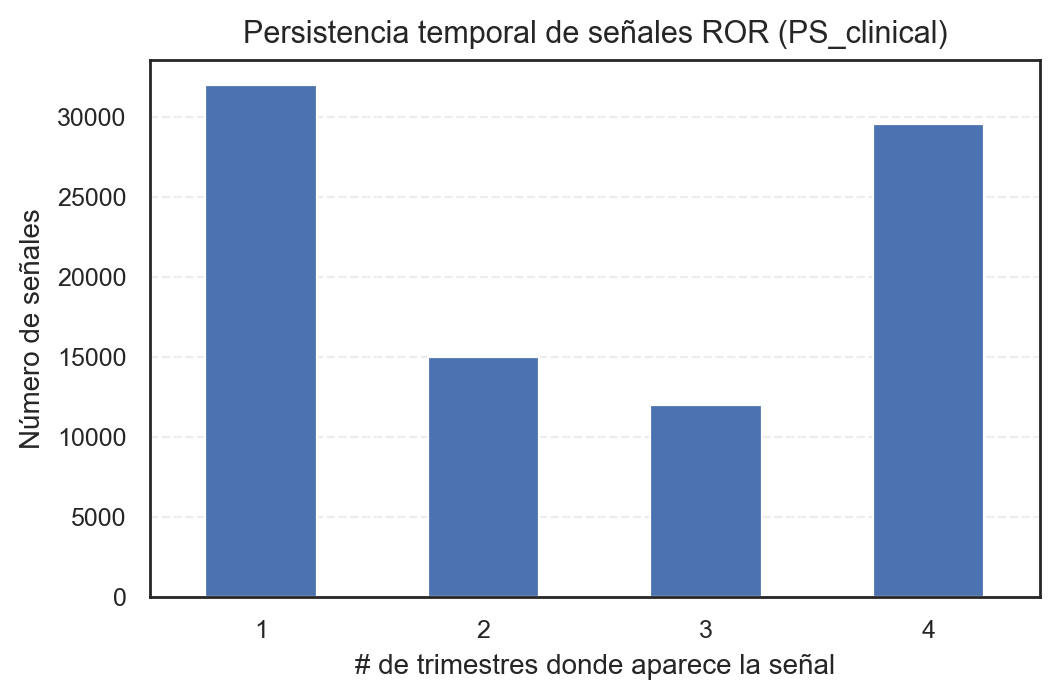

In [34]:
# distribución de persistencia (1–4 trimestres) 
persist_counts = (presence_mat["n_quarters_present"]
                  .value_counts()
                  .sort_index())

fig = plt.figure(figsize=(5.4, 3.6),dpi=200)
ax = plt.gca()
persist_counts.plot(kind="bar", ax=ax)
ax.set_title(f"Persistencia temporal de señales ROR ({TIME_LABEL})")
ax.set_xlabel("# de trimestres donde aparece la señal")
ax.set_ylabel("Número de señales")
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.tick_params(axis="x", labelrotation=0) 
plt.tight_layout()

out_fp = FIG_DIR / f"persistencia_barras_{TIME_LABEL}.png"
plt.savefig(out_fp, dpi=200, bbox_inches="tight")
plt.show()

La figura muestra la **distribución de persistencia temporal** de las señales positivas por ROR en el esquema **PS\_clinical**, es decir, cuántos pares fármaco–reacción aparecen como señal en **1, 2, 3 o 4 trimestres**. Se observa un patrón bimodal: un grupo grande de señales aparece en **un solo trimestre** (señales transitorias), mientras que otro grupo comparable aparece en **los cuatro trimestres** (señales altamente persistentes). En contraste, el número de señales que aparecen en **dos** o **tres** trimestres es menor. Este comportamiento sugiere la coexistencia de (i) señales potencialmente influenciadas por variabilidad temporal o bajo soporte, y (ii) un núcleo robusto de señales que se mantiene consistentemente a lo largo del año, útil para priorización y análisis posterior.

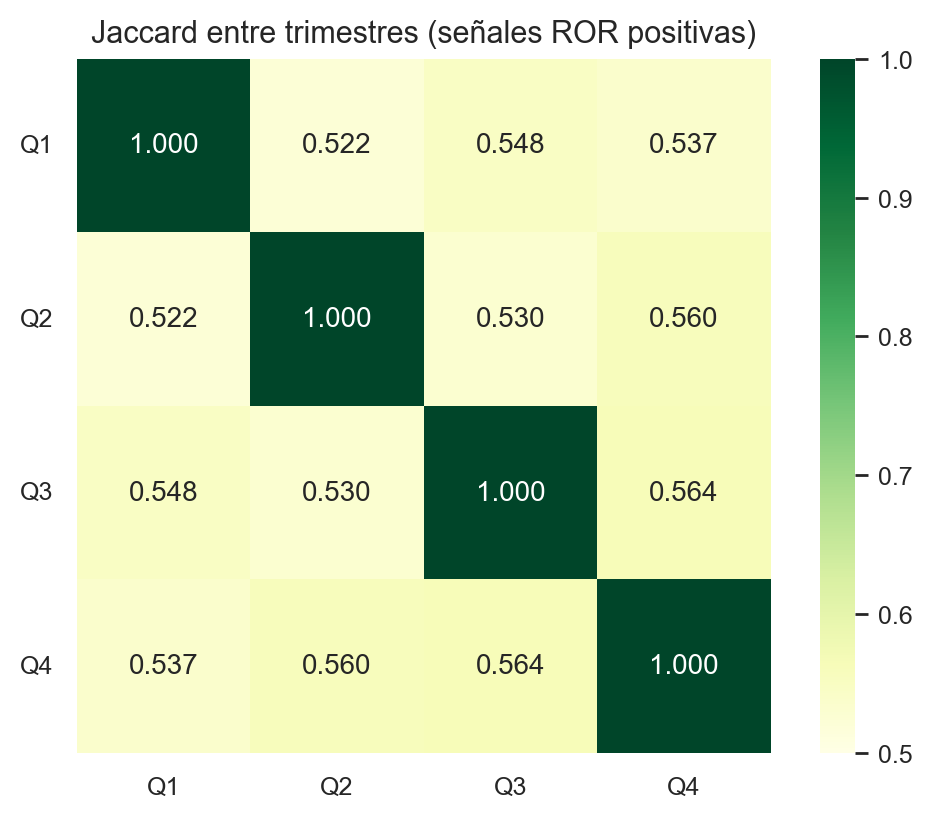

In [35]:
# Jaccard global (señales ROR) 
quarter_label_map = {
    "q1_2025_sample100k": "Q1",
    "q2_2025_sample100k": "Q2",
    "q3_2025_sample100k": "Q3",
    "q4_2025_sample100k": "Q4",
}
q_short = ["Q1", "Q2", "Q3", "Q4"]


jaccard_plot = jaccard_mat.copy()
jaccard_plot.index = [quarter_label_map.get(str(x), str(x)) for x in jaccard_plot.index]
jaccard_plot.columns = [quarter_label_map.get(str(x), str(x)) for x in jaccard_plot.columns]


if set(jaccard_plot.index) == set(q_short):
    jaccard_plot = jaccard_plot.loc[q_short, q_short]

fig = plt.figure(figsize=(5.4, 4.2), dpi=200)
ax = plt.gca()
sns.heatmap(
    jaccard_plot.astype(float),
    annot=True,
    fmt=".3f",
    ax=ax,
    square=True,
    cmap="YlGn",
    vmin=0.5, vmax=1
)
ax.set_title("Jaccard entre trimestres (señales ROR positivas)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()

out_fp = FIG_DIR / f"heatmap_jaccard_global_{TIME_LABEL}.png"
plt.savefig(out_fp, dpi=200, bbox_inches="tight")
plt.show()


La figura presenta un **heatmap del índice de Jaccard** entre trimestres (Q1–Q4) para el conjunto de **señales ROR positivas** bajo el esquema **PS\_clinical**. Los valores fuera de la diagonal (≈ **0.52–0.56**) indican una **similitud moderada** entre los conjuntos de señales de distintos trimestres: en promedio, alrededor de la mitad de las señales se mantiene compartida entre periodos, mientras que el resto corresponde a señales que aparecen o desaparecen temporalmente. La diagonal vale **1.0** por construcción (comparación del trimestre consigo mismo). En conjunto, el patrón sugiere que existe un componente estable de señales a lo largo del año, acompañado de variación trimestral esperable en datos de farmacovigilancia.

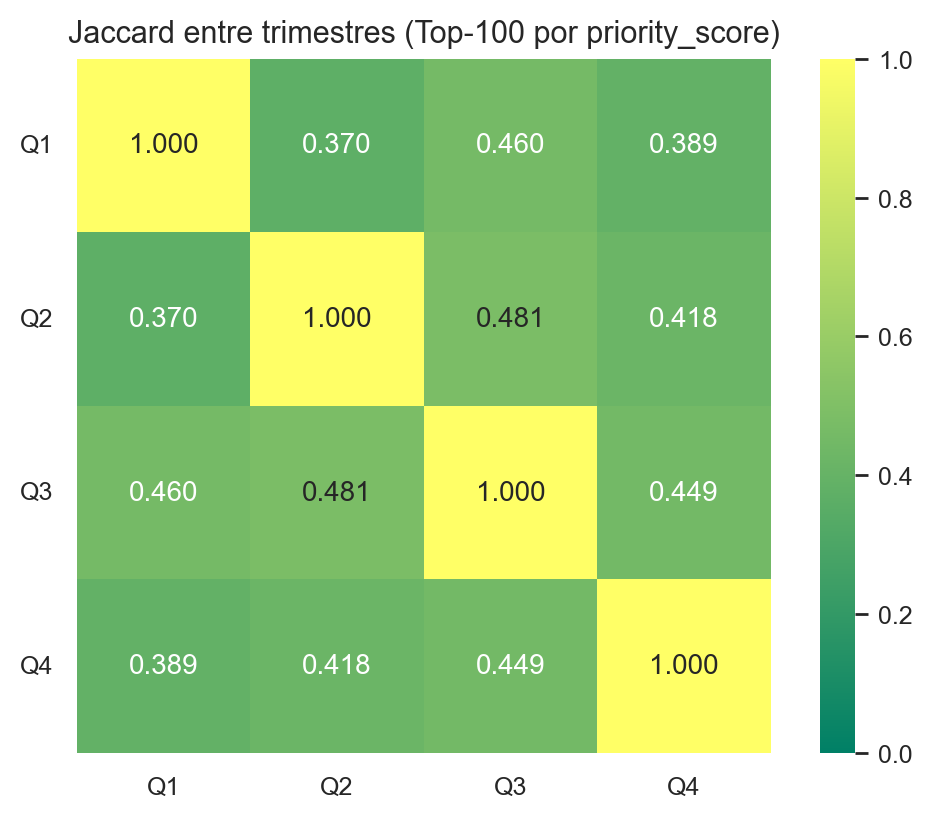

In [36]:
# Jaccard Top-k 

quarter_label_map = {
    "q1_2025_sample100k": "Q1",
    "q2_2025_sample100k": "Q2",
    "q3_2025_sample100k": "Q3",
    "q4_2025_sample100k": "Q4",
}
q_short = ["Q1", "Q2", "Q3", "Q4"]


jaccard_topk_plot = jaccard_topk.copy()
jaccard_topk_plot.index = [quarter_label_map.get(str(x), str(x)) for x in jaccard_topk_plot.index]
jaccard_topk_plot.columns = [quarter_label_map.get(str(x), str(x)) for x in jaccard_topk_plot.columns]


if set(jaccard_topk_plot.index) == set(q_short):
    jaccard_topk_plot = jaccard_topk_plot.loc[q_short, q_short]

fig = plt.figure(figsize=(5.4, 4.2), dpi=200)
ax = plt.gca()
sns.heatmap(
    jaccard_topk_plot.astype(float),
    annot=True,
    fmt=".3f",
    ax=ax,
    square=True,
    cmap="summer",
    vmin=0, vmax=1
)

ax.set_title(f"Jaccard entre trimestres (Top-{TOPK} por priority_score)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelrotation=0) 
plt.tight_layout()

out_fp = FIG_DIR / f"heatmap_jaccard_top{TOPK}_{TIME_LABEL}.png"
plt.savefig(out_fp, dpi=200, bbox_inches="tight")
plt.show()


La figura muestra el **heatmap del índice de Jaccard** entre trimestres (Q1–Q4) para el **Top-100** de señales ordenadas por `priority_score` (esquema **PS\_clinical**). Los valores fuera de la diagonal se sitúan aproximadamente entre **0.37 y 0.48**, lo que indica una **estabilidad moderada** del conjunto de señales prioritarias: entre cualquier par de trimestres, alrededor de **40%** del Top-100 tiende a coincidir, mientras que el resto cambia debido a variaciones en la frecuencia (`n11`) y/o la intensidad de señal (`ROR_L95`) que afectan el ranking. Como referencia, la diagonal es **1.0** por construcción. En conjunto, el gráfico sugiere que existe un núcleo recurrente de señales de alta prioridad, aunque la composición exacta del Top-100 presenta cambios trimestrales esperables en datos de farmacovigilancia.

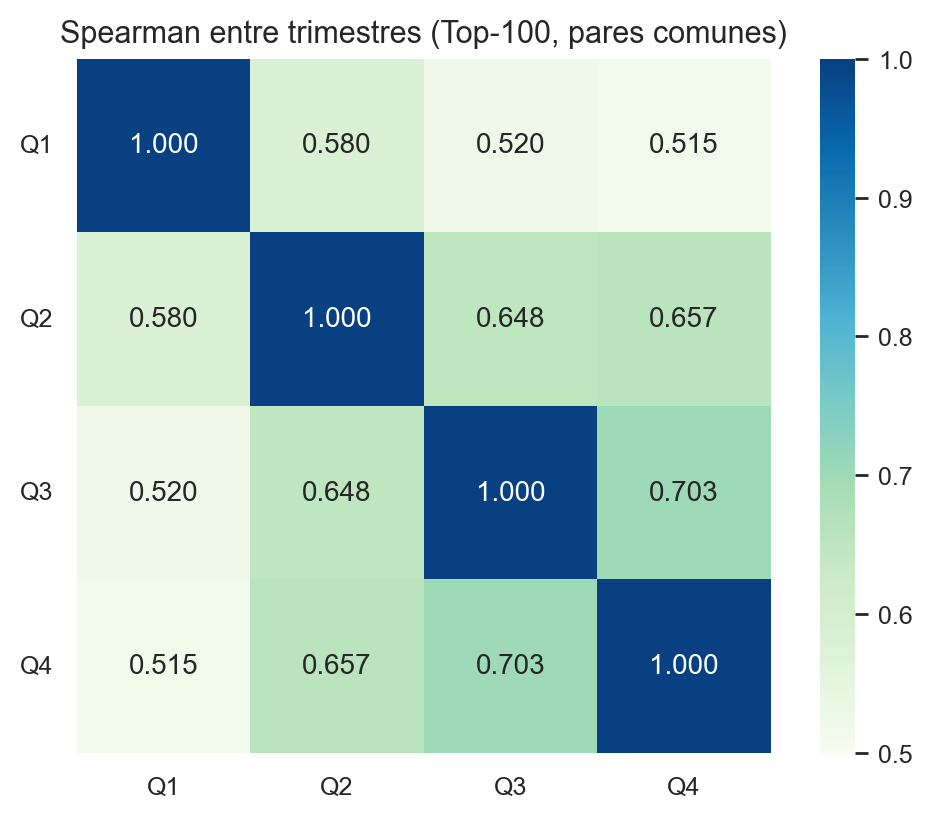

In [37]:
# Spearman Top-k 

quarter_label_map = {
    "q1_2025_sample100k": "Q1",
    "q2_2025_sample100k": "Q2",
    "q3_2025_sample100k": "Q3",
    "q4_2025_sample100k": "Q4",
}
q_short = ["Q1", "Q2", "Q3", "Q4"]


spearman_plot = spearman_mat.copy()
spearman_plot.index = [quarter_label_map.get(str(x), str(x)) for x in spearman_plot.index]
spearman_plot.columns = [quarter_label_map.get(str(x), str(x)) for x in spearman_plot.columns]


if set(spearman_plot.index) == set(q_short):
    spearman_plot = spearman_plot.loc[q_short, q_short]

fig = plt.figure(figsize=(5.4, 4.2), dpi=200)
ax = plt.gca()
sns.heatmap(
    spearman_plot.astype(float),
    annot=True,
    fmt=".3f",
    ax=ax,
    square=True,
    cmap='GnBu',
    vmin=0.5, vmax=1
)
ax.set_title(f"Spearman entre trimestres (Top-{TOPK}, pares comunes)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelrotation=0) 
plt.tight_layout()

out_fp = FIG_DIR / f"heatmap_spearman_top{TOPK}_{TIME_LABEL}.png"
plt.savefig(out_fp, dpi=200, bbox_inches="tight")
plt.show()

La figura muestra el **heatmap de la correlación de Spearman** entre trimestres (Q1–Q4) para el **Top-100** de señales (ordenadas por `priority_score`), calculada **únicamente sobre los pares comunes** entre cada par de trimestres. Los valores fuera de la diagonal se ubican aproximadamente entre **0.52 y 0.70**, lo que indica una **consistencia moderada** en el orden de priorización: cuando una señal aparece en el Top-100 de dos trimestres, su posición relativa tiende a preservarse en buena medida. La concordancia es mayor entre trimestres consecutivos hacia el final del año (por ejemplo, **Q3 vs Q4** con $\rho\approx 0.70$), lo cual sugiere un ranking más estable en ese periodo. La diagonal toma el valor **1.0** por construcción. En conjunto, el gráfico respalda la existencia de un núcleo de señales prioritarias cuyo orden relativo es razonablemente reproducible a lo largo del tiempo.

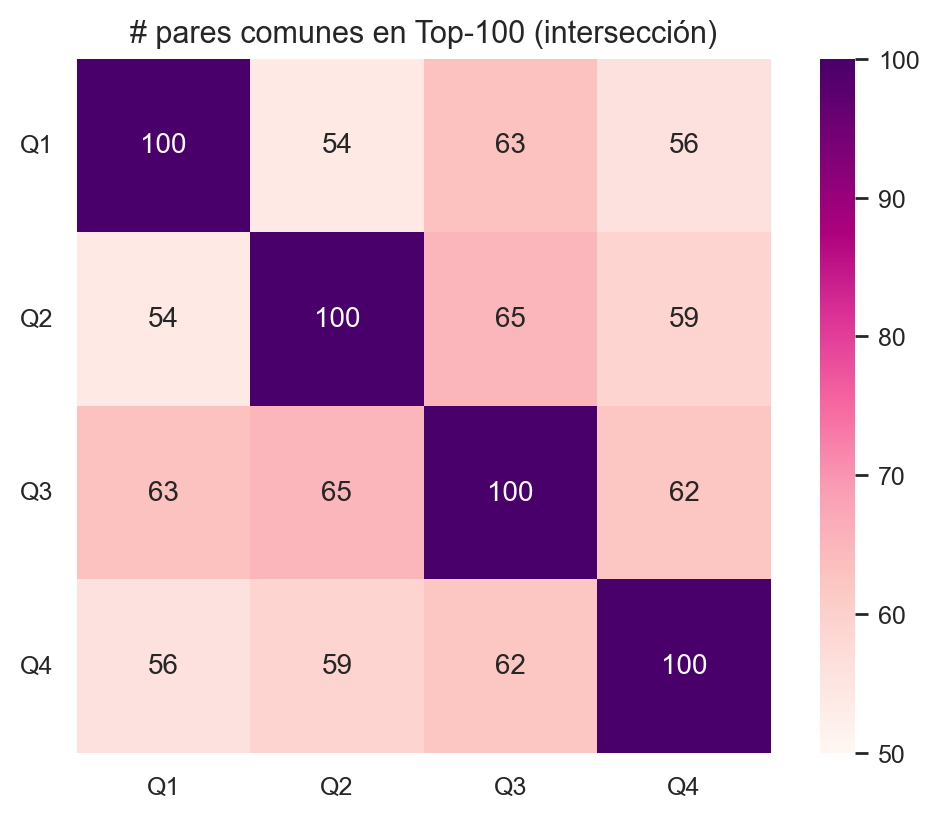

In [40]:
# no. pares comunes Top-k 

quarter_label_map = {
    "q1_2025_sample100k": "Q1",
    "q2_2025_sample100k": "Q2",
    "q3_2025_sample100k": "Q3",
    "q4_2025_sample100k": "Q4",
}
q_short = ["Q1", "Q2", "Q3", "Q4"]

n_common_plot = n_common_mat.copy()
n_common_plot.index = [quarter_label_map.get(str(x), str(x)) for x in n_common_plot.index]
n_common_plot.columns = [quarter_label_map.get(str(x), str(x)) for x in n_common_plot.columns]


if set(n_common_plot.index) == set(q_short):
    n_common_plot = n_common_plot.loc[q_short, q_short]

fig = plt.figure(figsize=(5.4, 4.2), dpi=200)
ax = plt.gca()
sns.heatmap(
    n_common_plot.astype(float),
    annot=True,
    fmt=".0f",
    ax=ax,
    square=True,
    cmap='RdPu',
    vmin=50, vmax=100
)
ax.set_title(f"# pares comunes en Top-{TOPK} (intersección)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelrotation=0) 
plt.tight_layout()

out_fp = FIG_DIR / f"heatmap_n_common_top{TOPK}_{TIME_LABEL}.png"
plt.savefig(out_fp, dpi=200, bbox_inches="tight")
plt.show()

La figura muestra un **heatmap del número de pares comunes** en el **Top-100** de señales (por `priority_score`) entre trimestres (Q1–Q4), es decir, el tamaño de la intersección $|Top_{100}(Q_i)\cap Top_{100}(Q_j)|$. Por construcción, la diagonal vale **100** (un trimestre comparado consigo mismo). Fuera de la diagonal, las intersecciones oscilan entre **54 y 65** pares, lo que indica que **más de la mitad** de las señales prioritarias se repiten entre trimestres. Los valores relativamente más altos se observan entre **Q2–Q3 (65)** y **Q1–Q3 (63)**, mientras que las comparaciones con menor coincidencia (por ejemplo, **Q1–Q2 = 54**) sugieren cambios moderados en la composición del Top-100. En conjunto, este gráfico cuantifica de forma directa la estabilidad del conjunto de señales más relevantes a lo largo del año y proporciona el contexto necesario para interpretar las correlaciones de ranking (Spearman) calculadas sobre los pares compartidos.

In [39]:
# tablas + exportables CSV (PS_clinical)

OUT_DIR = Path("outputs_temporal_stability")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Guardar resumen por trimestre
summary_quarters.to_csv(OUT_DIR / f"summary_quarters_{TIME_LABEL}.csv", index=False)

# Guardar distribución de persistencia
persist_dist = (presence_mat["n_quarters_present"]
                .value_counts()
                .sort_index()
                .rename_axis("n_quarters_present")
                .reset_index(name="n_signals"))
persist_dist.to_csv(OUT_DIR / f"persist_dist_{TIME_LABEL}.csv", index=False)

# Tabla de señales persistentes (4/4) con agregados entre trimestres
nQ = len(quarter_order)
persistent_all = presence_mat.loc[presence_mat["n_quarters_present"] == nQ].copy()

# Agregar métricas a través de trimestres 
if not presence_long.empty:
    summary_persist = (presence_long
        .groupby(["pair_id", "drug_key", "reaction_pt"], as_index=False)
        .agg(
            n_quarters_present=("quarter", "nunique"),
            total_n11=("n11", "sum"),
            mean_n11=("n11", "mean"),
            median_n11=("n11", "median"),
            mean_ROR_L95=("ROR_L95", "mean"),
            median_ROR_L95=("ROR_L95", "median"),
            mean_PRR=("PRR", "mean"),
            median_PRR=("PRR", "median"),
        )
    )

    # incorporar presencia por trimestre para tabla
    summary_persist = summary_persist.merge(
        presence_mat[["pair_id"] + quarter_order + ["n_quarters_present"]],
        on=["pair_id", "n_quarters_present"],
        how="left"
    )

    # quedarnos con persistentes 4/4
    summary_persist_4q = summary_persist.loc[summary_persist["n_quarters_present"] == nQ].copy()

    # Orden: persistencia, soporte, intensidad
    summary_persist_4q = summary_persist_4q.sort_values(
        ["total_n11", "mean_ROR_L95"],
        ascending=[False, False]
    ).reset_index(drop=True)

    # Guardar tabla completa 4/4
    summary_persist_4q.to_csv(OUT_DIR / f"signals_persistent_{nQ}of{nQ}_{TIME_LABEL}.csv", index=False)

    # Guardar top-50 persistentes para tabla del paper
    top_persist_cols = (["drug_key", "reaction_pt", "n_quarters_present"] +
                        quarter_order +
                        ["total_n11", "mean_n11", "median_n11", "mean_ROR_L95", "median_ROR_L95", "mean_PRR", "median_PRR"])
    top_persist_50 = summary_persist_4q[top_persist_cols].head(50).copy()
    top_persist_50.to_csv(OUT_DIR / f"top50_persistent_{nQ}of{nQ}_{TIME_LABEL}.csv", index=False)

    top_persist_50.head(15)
else:
    print("[WARN] presence_long está vacío; no se puede construir summary_persist.")

# Guardar matrices de estabilidad 
jaccard_mat.to_csv(OUT_DIR / f"jaccard_global_{TIME_LABEL}.csv")
jaccard_topk.to_csv(OUT_DIR / f"jaccard_top{TOPK}_{TIME_LABEL}.csv")
spearman_mat.to_csv(OUT_DIR / f"spearman_top{TOPK}_{TIME_LABEL}.csv")
n_common_mat.to_csv(OUT_DIR / f"n_common_top{TOPK}_{TIME_LABEL}.csv")

# Guardar presencia matrix y long 
presence_long.to_csv(OUT_DIR / f"presence_long_{TIME_LABEL}.csv", index=False)
presence_mat.to_csv(OUT_DIR / f"presence_matrix_{TIME_LABEL}.csv", index=False)

La tabla `top_persist_50` (mostrada en `head(15)`) presenta ejemplos de las **señales más persistentes** (con `n_quarters_present = 4`), es decir, pares fármaco–reacción que aparecen como señales ROR positivas en **todos los trimestres (Q1–Q4)**. Además de las columnas binarias de presencia por trimestre (valores 1 en `q1_...` a `q4_...`), la tabla resume la **fuerza y soporte** agregados en el tiempo: `total_n11` (suma de co-ocurrencias), `mean_n11`/`median_n11` (frecuencia promedio/mediana por trimestre), y estadísticas de intensidad como `mean_ROR_L95`/`median_ROR_L95` y `mean_PRR`/`median_PRR`. En estos ejemplos se observa un núcleo estable dominado por **DUPILUMAB** asociado a eventos clínicamente plausibles y frecuentes (p. ej., *PRURITUS*, *DERMATITIS ATOPIC*, *RASH*, *ECZEMA*), así como otros pares persistentes como **RELUGOLIX–HOT FLUSH** y **VEDOLIZUMAB–COLITIS ULCERATIVE**. En conjunto, esta tabla permite identificar señales que no solo son intensas, sino también **reproducibles temporalmente**, lo cual es clave para priorización en un análisis de estabilidad.

En **PS_clinical**, al calcular señales por trimestre (Q1–Q4) se observó un volumen muy consistente de reportes (≈94–95 mil por trimestre) y de pares evaluados (≈302k–328k), con **señales ROR positivas** en el rango de **50,431–56,644** por trimestre. El análisis de persistencia mostró una estructura bimodal: **31,982** señales aparecen en **un solo trimestre**, mientras que **29,578** señales son **persistentes 4/4**, sugiriendo la coexistencia de señales transitorias (potencialmente sensibles a rareza, mezcla de reportes o variación temporal) y un núcleo robusto de señales estables. La similitud entre trimestres medida por Jaccard en el conjunto global de señales fue **moderada** (≈0.52–0.56), indicando que alrededor de la mitad de las señales se mantiene entre periodos. Para el **Top-100** por `priority_score`, la similitud disminuye (Jaccard ≈0.37–0.48), como es esperable en un ranking más sensible; sin embargo, la intersección entre Top-100 se mantuvo alta (**54–65** pares comunes) y el orden relativo de los pares compartidos fue **moderadamente consistente** (Spearman ≈0.51–0.70, con mayor concordancia en Q3–Q4). En conjunto, estos resultados apoyan que el pipeline produce un conjunto sustancial de señales **reproducibles temporalmente**, y que la priorización por `priority_score` conserva un núcleo estable a pesar de variaciones trimestrales; adicionalmente, el filtrado `clinical-only` ayuda a enfocar la interpretación en términos más clínicos sin eliminar la posibilidad de analizar por separado señales operacionales.

Como conclusión, el análisis de estabilidad temporal evidencia que, bajo el esquema **PS_clinical**, existe un **núcleo grande y persistente** de señales ROR (≈29.6k presentes en los cuatro trimestres), acompañado por señales transitorias que justifican análisis de sensibilidad (p. ej., variar `MIN_N11` o evaluar estabilidad Top-k). Las matrices de Jaccard y Spearman muestran una estabilidad global moderada y una estabilidad del Top-100 suficiente para sostener la reproducibilidad del ranking de priorización a lo largo del año, lo que fortalece la utilidad del enfoque para priorizar señales candidatas a revisión clínica posterior y para sustentar un manuscrito con evidencia temporal de robustez.
